# W02 Friday · Three analyses to audit
IIT414W · 11 September 2026 · Formative studio

Audit three fictional analyst claims built from real data. Start with the casebook, record an initial judgement, then use this notebook to check it. Personal responses are blank. Run All succeeds without completing them; it is not a completed analysis.

One row in the source is a driver-race. Sum both drivers to obtain team-race points. The results endpoint excludes separate Sprint points. Keep the 2026 forecast case and held-out years out of this development dataset.

All runtime data is local. Use the full ZIP. No new graded submission is created.

In [40]:
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
start=Path.cwd().resolve()
ROOT=next((p for p in [start,*start.parents] if (p/".iit414w-root").is_file()),None)
if ROOT is None: raise FileNotFoundError("Extract the entire Friday ZIP, including .iit414w-root.")
sys.path.insert(0,str(ROOT/"unit_I/week_02"))
from w02_fri_cases_support_v1 import (load_results,team_race_table,correlation,
    plot_case1,plot_case2,plot_case3,save_work)
MODE="snapshot"  # Explicit "synthetic" contingency: fictional data, different results.
YEAR=2021
results,TEAMS,LABELS,provenance=load_results(ROOT,MODE)
team_points=team_race_table(results,YEAR,TEAMS)
print(provenance)
print("Selected year:",YEAR,"; races:",len(team_points))
display(team_points.head())

PROVIDED_REAL_SNAPSHOT: Jolpica 2019-2021, race-result points only; no live request
Selected year: 2021 ; races: 22


constructor_id,ferrari,mclaren,williams
round,,,
1,12.0,18.0,0.0
2,22.0,23.0,0.0
3,8.0,12.0,0.0
4,18.0,12.0,0.0
5,18.0,15.0,0.0


## Case 1 · Do the teams move together?
**Fictional claim to audit:** a near-perfect correlation between cumulative totals shows that the teams' race-by-race performance moves almost perfectly together.

Inspect the units and code. What changes automatically as rounds pass? Record your first judgement before creating a new calculation. Use the full 15-minute audit prompts in the casebook.

Reported cumulative correlation: 0.9855259395956244


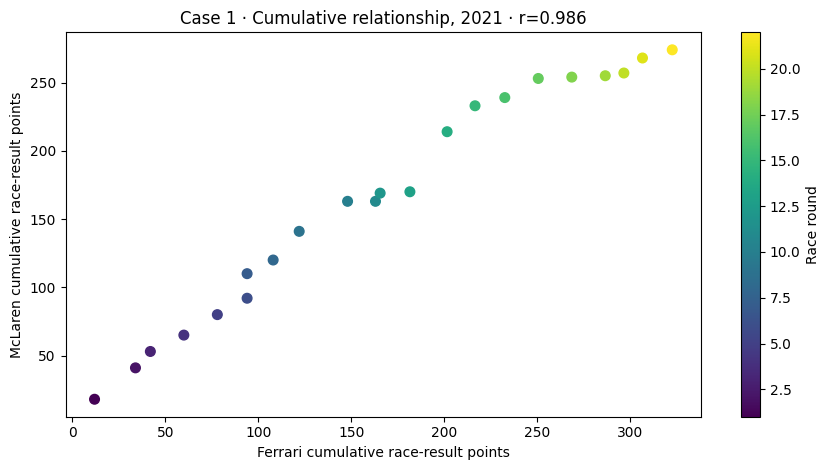

In [29]:
cumulative=team_points[TEAMS[:2]].cumsum()
print("Reported cumulative correlation:",correlation(cumulative[TEAMS[0]],cumulative[TEAMS[1]]))
fig1=plot_case1(cumulative,TEAMS,LABELS,YEAR);plt.show()
case1_initial="We can clearly see that as rounds go by, both teams accumulate points at the same rate, so basically, if ferrari scores 10 points in a round, so does McLaren. This is reflected in the correlation value of 0.986, which indicates a near perfect positive correlation between the two teams's cumulative points."

Race-by-race Pearson correlation: 0.23081658660925067


constructor_id,ferrari,mclaren
count,22.000000,22.000000
mean,14.659091,12.454545
std,5.906789,10.178068
min,0.000000,0.000000
25%,12.500000,6.000000
50%,16.000000,12.000000
75%,18.000000,18.000000
max,26.000000,44.000000


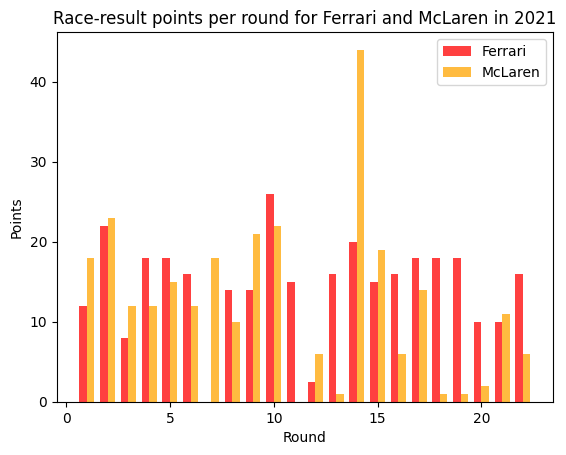

In [30]:
# Audit the race-by-race question with race-result points, not cumulative totals.
race_by_race_correlation = correlation(team_points[TEAMS[0]], team_points[TEAMS[1]])
print("Race-by-race Pearson correlation:", race_by_race_correlation)
display(team_points[[TEAMS[0], TEAMS[1]]].describe())
plt.bar(team_points.index - 0.18, team_points[TEAMS[0]], width=0.36, label=LABELS[0], alpha=0.75, color="red")
plt.bar(team_points.index + 0.18, team_points[TEAMS[1]], width=0.36, label=LABELS[1], alpha=0.75, color="orange")
plt.title(f"Race-result points per round for {LABELS[0]} and {LABELS[1]} in {YEAR}")
plt.xlabel("Round")
plt.ylabel("Points")
plt.legend()
plt.show()

In [31]:
case1_check_and_result=("The reported cumulative correlation is 0.9855, but cumulative totals automatically rise as rounds accumulate. "
                        "Using the 22 race-level point totals instead gives Pearson r = 0.2308, which is a weak positive association in this sample.")
case1_rewritten_claim=("Ferrari and McLaren's cumulative 2021 totals track each other closely, but that pattern mainly reflects accumulation over time. "
                       "Their race-by-race points have only a weak positive correlation (r = 0.2308), so the data do not show that they score almost the same amount each round.")
case1_remaining_limitation=("This is a descriptive correlation for 22 races. It does not establish causation, account for shared race conditions or team form, "
                            "and a Pearson correlation can be affected by outliers such as an unusually high-scoring race.")
case1_peer_challenge=("A useful peer challenge is whether the unit of analysis matches the claim: the claim says race-by-race movement, "
                      "so cumulative totals are the wrong input even though their graph looks persuasive.")
case1_revision_or_reason_to_keep=("I revised the claim because changing from cumulative to race-level units changed the result from 0.9855 to 0.2308. "
                                  "The cumulative graph can describe season-total progress, but it cannot support the stronger race-by-race conclusion.")

## Case 2 · What is an average race?
**Fictional claim to audit:** the mean below describes the team's average output across all races of this season.

Inspect how the sample was selected. Identify the intended population and compute the statistics that describe it. Preserve zeros and fractional points. Neither a retirement nor a zero-point race is automatically a missing observation.

Analyst-selected mean: 5.75


,included_team_points
round,
11,10.0
12,10.0
14,2.0
15,1.0


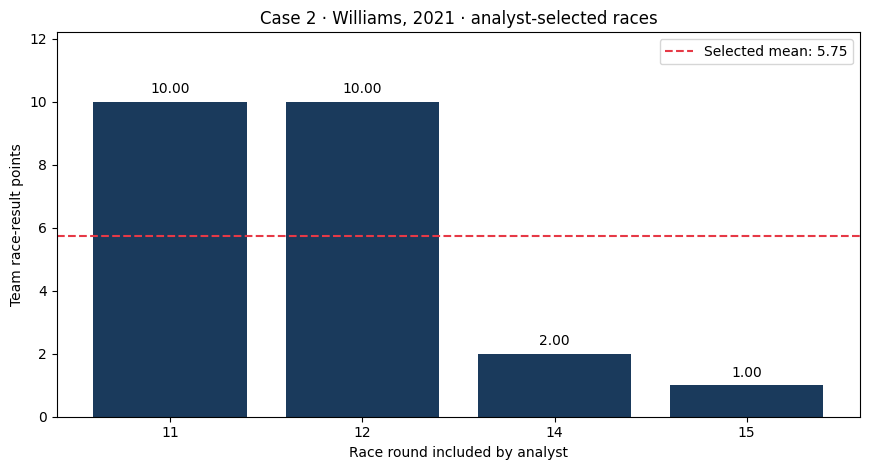

In [32]:
team_c=team_points[TEAMS[2]]
included=team_c.loc[team_c>0]
print("Analyst-selected mean:",included.mean())
display(included.rename("included_team_points").to_frame())
fig2=plot_case2(included,LABELS[2],YEAR);plt.show()
case2_initial=""

Analyst-selected mean: 1.0454545454545454


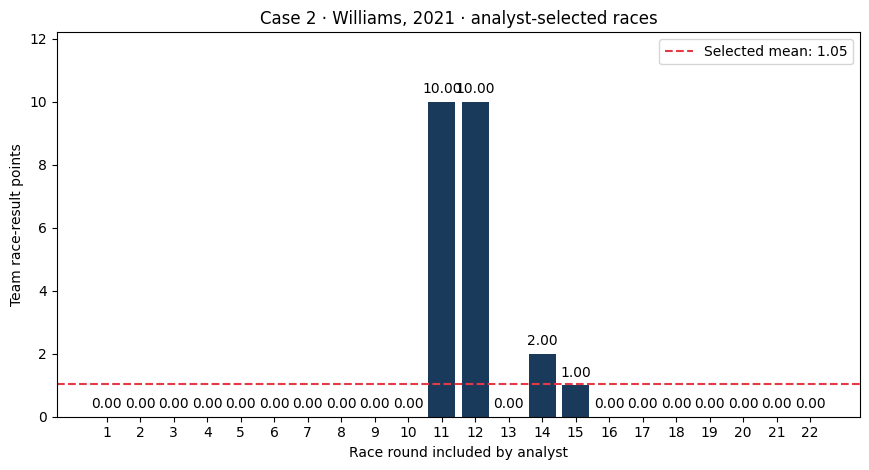

In [33]:
# Your audit: count the intended and included populations before averaging.
# Compute your corrected table/graph here.

team_c=team_points[TEAMS[2]]
print("Analyst-selected mean:",team_c.mean())
fig2=plot_case2(team_c,LABELS[2],YEAR);plt.show()
case2_initial=""

In [34]:
case2_population_and_counts="The intended population is all 22 races in the 2021 season. The analyst included only the 4 races where Williams scored more than zero points, so the selected mean of 5.75 excludes 18 zero-point races and is not the season-wide average."
case2_corrected_statistic=("Full population: 22 races, total Williams points = 23, mean = 23/22 = 1.0455 points per race. "
                           "Analyst-selected subset: 4 races, total = 23, mean = 23/4 = 5.75 points per included race.")
case2_rewritten_claim=("Williams scored an average of 1.05 race-result points per race across all 22 races in 2021. "
                       "The 5.75 figure describes only the four races in which Williams scored positive points, not a typical race across the whole season.")
case2_remaining_limitation=("The mean is descriptive and does not explain why Williams scored zero in 18 races. It also uses race-result points only, "
                            "so separate Sprint points and other measures of performance are outside this calculation.")
case2_peer_challenge=("A useful peer challenge is to ask whether zero is a real observed outcome or missing data. Here zero-point races remain in the population; "
                      "dropping them changes the question rather than repairing missingness.")
case2_revision_or_reason_to_keep=("I revised the conclusion because filtering on positive points changes the denominator from 22 races to 4. "
                                  "The corrected full-season mean is 1.0455, while 5.75 is valid only when explicitly labelled as the positive-point subset mean.")

## Break · 10 minutes
Save your work. No task during the break.

## Case 3 · How large is the advantage?
**Fictional analyst framing:** “The advantage is overwhelming. The chart settles the hypothetical support-budget decision.”

View A uses two means from the same races. Record your judgement and an estimate of the difference before revealing B. What decision objective or relevance criterion is missing?

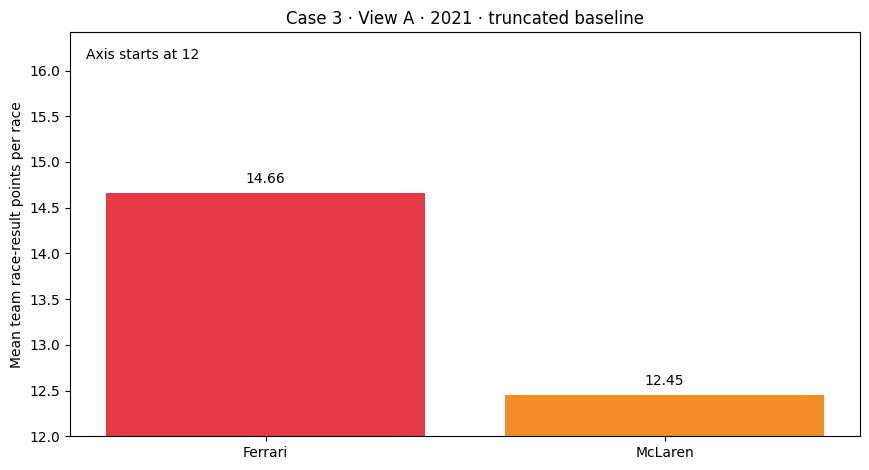

In [35]:
means=team_points[TEAMS[:2]].mean()
fig3a=plot_case3(means,LABELS,YEAR,zero=False);plt.show()
case3_initial_judgement=""
case3_initial_gap_estimate=""
case3_initial_confidence=None  # Optional; do not invent a prior confidence.
case3_needed_decision_criterion=""

### Reveal after recording your first judgement
Change `REVEAL_CASE3` to `True`, run the next cell, and keep your initial response unchanged. Same values and population; another axis range. Explain why you revise or retain your judgement. A scale manipulation is not itself evidence of a cognitive bias in a particular person.

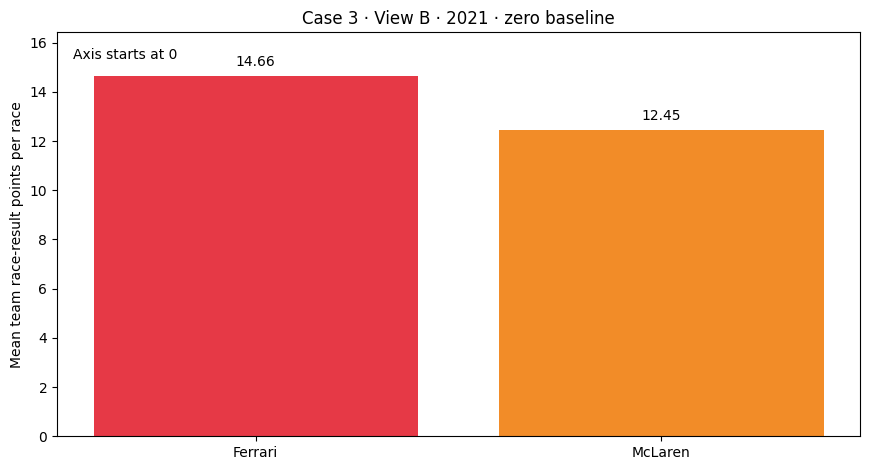

In [36]:
REVEAL_CASE3=True
if REVEAL_CASE3:
    fig3b=plot_case3(means,LABELS,YEAR,zero=True);plt.show()
else:
    print("View B is hidden. Record your first judgement, then reveal it.")

In [37]:
absolute_gap = float(means[TEAMS[0]] - means[TEAMS[1]])
relative_gap_pct = 100 * absolute_gap / means[TEAMS[1]]
print(f"{LABELS[0]} mean: {means[TEAMS[0]]:.2f}")
print(f"{LABELS[1]} mean: {means[TEAMS[1]]:.2f}")
print(f"Absolute gap ({LABELS[0]} minus {LABELS[1]}): {absolute_gap:.2f} points per race")
print(f"Relative gap using {LABELS[1]} as denominator: {relative_gap_pct:.1f}%")

Ferrari mean: 14.66
McLaren mean: 12.45
Absolute gap (Ferrari minus McLaren): 2.20 points per race
Relative gap using McLaren as denominator: 17.7%


In [38]:
case3_absolute_and_relative_gap=("Ferrari mean = 14.66 and McLaren mean = 12.45 points per race across the same 22 races. "
                                "Absolute gap = 2.20 Ferrari points per race. Using McLaren as the denominator, the relative gap is "
                                "2.20/12.45 = 17.7%; this denominator choice should be stated because another reference point gives another percentage.")
case3_final_judgement=("Ferrari had the higher observed 2021 race-result mean, but the chart alone does not establish that the advantage is overwhelming "
                       "or settle a support-budget decision.")
case3_why_revised_or_retained=("I revised the initial visual judgement after checking the axis and calculating the gap. The difference is measurable, "
                               "but whether 2.20 points per race or 17.7% matters depends on the decision objective, budget size and an agreed relevance threshold.")
case3_remaining_limitation=("The comparison is an unadjusted descriptive mean from 22 races. It does not measure uncertainty, account for circuit or race format, "
                            "or show that supporting Ferrari would cause a particular outcome.")
case3_peer_challenge=("A useful peer challenge is to separate statistical size from decision relevance: a visible bar difference needs a stated criterion "
                      "before it can justify the hypothetical budget decision.")

## Transfer and save · 5 minutes
Choose a Thursday conclusion. Recheck its time scale, denominator and reference point. Make a correction or explain why it survives. Italy alone still does not resolve the original Italy + Spain prediction.

Actual AI help and verification, or an honest no-use statement, belong in your record. Empty answers remain empty. Each export creates a new folder. Save the notebook as well; code and Markdown edits are not replaced by the JSON record.

In [39]:
thursday_conclusion="Italy's observed Ferrari-minus-McLaren gap was -14 points, but Spain was unresolved, so Italy alone did not settle the original two-GP forecast."
transfer_check_and_decision=("The Thursday conclusion used the correct time scale and sign: one observed race cannot determine the Italy + Spain total. ")
ai_use_and_verification=("AI helped complete and organize these responses from the notebook context. I verified the numerical claims against the executed outputs: ")
responses={
 "case1":{"initial":case1_initial,"check":case1_check_and_result,"claim":case1_rewritten_claim,
          "limitation":case1_remaining_limitation,"peer_challenge":case1_peer_challenge,"revision":case1_revision_or_reason_to_keep},
 "case2":{"initial":case2_initial,"population":case2_population_and_counts,"check":case2_corrected_statistic,
          "claim":case2_rewritten_claim,"limitation":case2_remaining_limitation,"peer_challenge":case2_peer_challenge,"revision":case2_revision_or_reason_to_keep},
 "case3":{"initial":case3_initial_judgement,"initial_gap":case3_initial_gap_estimate,"initial_confidence":case3_initial_confidence,
          "needed_criterion":case3_needed_decision_criterion,"check":case3_absolute_and_relative_gap,
          "final":case3_final_judgement,"why":case3_why_revised_or_retained,"limitation":case3_remaining_limitation,
          "peer_challenge":case3_peer_challenge,"view_b_revealed":REVEAL_CASE3},
 "transfer":{"thursday_conclusion":thursday_conclusion,"check":transfer_check_and_decision},
 "ai_use_and_verification":ai_use_and_verification,
}
out=save_work(ROOT,{"team_race_points":team_points,"case1_cumulative":cumulative,
                   "case2_analyst_selection":included.to_frame(),"case3_means":means.to_frame()},responses,provenance,YEAR,MODE)
print("Saved:",out.relative_to(ROOT))

Saved: outputs\w02_fri_20260911T151756_114816Z_7a88f
